# Modélisation:



In [9]:
##================ Chargement de quelques modules de base ===================
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (learning_curve, cross_val_score, validation_curve, StratifiedKFold)
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline


In [10]:
##============= Synchronisation pour permettre les import dans src en particulier ============
# Réglages d'affichage
pd.set_option("display.max_columns", 21)
# Toujours afficher la dimension du dataframe
pd.set_option("display.show_dimensions", True)

# Chemin absolue

project_root = Path.cwd().resolve().parents[0]
src_path = project_root / "src"

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [11]:
##============== chargement des modules spécifiques à la modélisation ========
from sklearn.metrics import ( accuracy_score, f1_score, roc_auc_score, precision_score, 
                   recall_score, confusion_matrix, classification_report,
                   balanced_accuracy_score, brier_score_loss, average_precision_score)
from src.config import RAW_DATA_PATH, TARGET_COL, RANDOM_STATE
from src.utils import load_csv
from src.features import add_features
from src.preprocessing import split_data, build_preprocessor

In [12]:
##============ Chargement des données ==============

df_raw = load_csv(RAW_DATA_PATH)
df = df_raw.copy()

## Préparation des données pour la modélisation

In [13]:
##============= Nettoyage dataset et ajout des trois variables créer lors features engineering ===============

df = add_features(df)

##======= matrice des features X & variable cible y ===========

X = df.drop(columns = [TARGET_COL])

y= df[TARGET_COL]

##=============== encodage de la variable cible ===========

y = df[TARGET_COL].map({"No": 0, "Yes": 1})

##============ Decoupage des données ======================

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, random_state=RANDOM_STATE)

##============== Variables numériques, catégoriques et construction du pipeline de pré-traitement =====

preprocessor, num_cols, cat_cols = build_preprocessor(X_train)



## Fonction d'évaluation

In [14]:
def evaluation(model):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state= RANDOM_STATE)
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    y_proba= model.predict_proba(X_val)[:,1]
    
    
    dict_of_predict = {"precision":precision_score,
                       "recal":recall_score,
                       "f1_score":f1_score,
                       "class_report":classification_report,
                       "confusion_matrix":confusion_matrix,
                       "balance_accuracy":balanced_accuracy_score
                      }
    
    dict_of_proba = {"roc_auc":roc_auc_score,
                       "pr_auc":average_precision_score,
                       "brier":brier_score_loss
                      }
    for name, metric in dict_of_predict.items():
        print(f'{name :-<50} {metric(y_val, y_pred_val)}')
    for name, metric in dict_of_proba.items():
        print(f'{name :-<50} {metric(y_val, y_proba)}')
    
     
    
    N, train_score, val_score = learning_curve(model, X_train, y_train, cv=cv, scoring="f1",
                                               train_sizes= np.linspace(0.1, 1, 10)
                                              )
    plt.figure(figsize = (12, 8))
    plt.plot(N, train_score.mean(axis=1), label="train_score")
    plt.plot(N, val_score.mean(axis=1), label="val_score")
    plt.legend()
    plt.show()
    
    

## Importation des estimateurs à tester

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

In [8]:
##================= creation de pipelines ===========

Logistic= Pipeline(steps=[("preprocessor", preprocessor), 
                          ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                          random_state=RANDOM_STATE))
                         ])
RandomForest= Pipeline(steps=[("preprocessor", preprocessor), 
                          ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                          random_state=RANDOM_STATE))
                         ])
XGBoost= Pipeline(steps=[("preprocessor", preprocessor), 
                          ("model", XGBClassifier())
                         ])
Dummy= Pipeline(steps=[("preprocessor", preprocessor), 
                          ("model", DummyClassifier())
                         ])

In [17]:
##============ dictionnaire des modèles choisis ==========
dict_of_model={"Logistic":Logistic,
               "RandomForest":RandomForest,
               "XGBoost":XGBoost,
               "Dummy":Dummy
              }

Logistic
precision----------------------------------------- 0.510250569476082
recal--------------------------------------------- 0.797153024911032
f1_score------------------------------------------ 0.6222222222222222
class_report--------------------------------------               precision    recall  f1-score   support

           0       0.91      0.72      0.80       774
           1       0.51      0.80      0.62       281

    accuracy                           0.74      1055
   macro avg       0.71      0.76      0.71      1055
weighted avg       0.80      0.74      0.76      1055

confusion_matrix---------------------------------- [[559 215]
 [ 57 224]]
balance_accuracy---------------------------------- 0.7596876235666271
roc_auc------------------------------------------- 0.8472026814532816
pr_auc-------------------------------------------- 0.657906489700712
brier--------------------------------------------- 0.16590113388185188


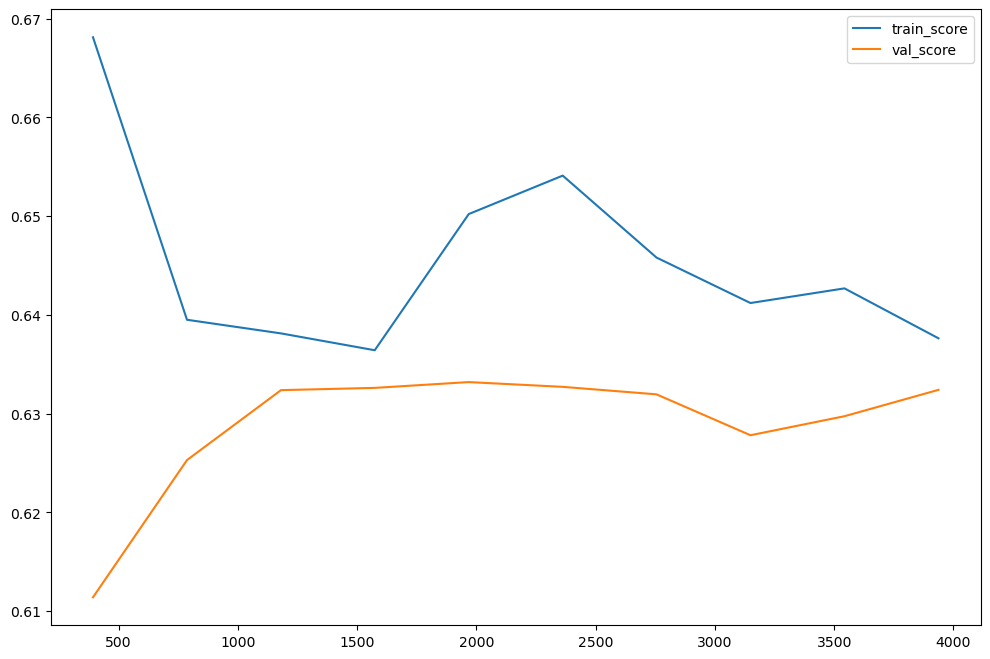

RandomForest
precision----------------------------------------- 0.6571428571428571
recal--------------------------------------------- 0.49110320284697506
f1_score------------------------------------------ 0.5621181262729125
class_report--------------------------------------               precision    recall  f1-score   support

           0       0.83      0.91      0.87       774
           1       0.66      0.49      0.56       281

    accuracy                           0.80      1055
   macro avg       0.74      0.70      0.71      1055
weighted avg       0.78      0.80      0.79      1055

confusion_matrix---------------------------------- [[702  72]
 [143 138]]
balance_accuracy---------------------------------- 0.6990399735165107
roc_auc------------------------------------------- 0.8220180786596412
pr_auc-------------------------------------------- 0.6197815233393213
brier--------------------------------------------- 0.1452579105014165


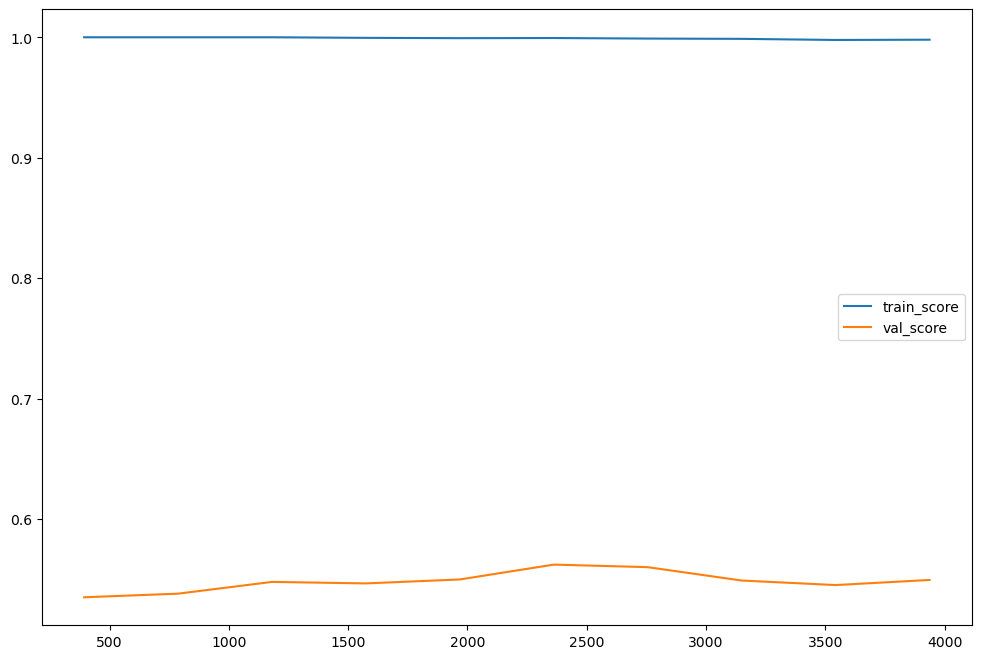

XGBoost
precision----------------------------------------- 0.6150793650793651
recal--------------------------------------------- 0.5516014234875445
f1_score------------------------------------------ 0.5816135084427767
class_report--------------------------------------               precision    recall  f1-score   support

           0       0.84      0.87      0.86       774
           1       0.62      0.55      0.58       281

    accuracy                           0.79      1055
   macro avg       0.73      0.71      0.72      1055
weighted avg       0.78      0.79      0.78      1055

confusion_matrix---------------------------------- [[677  97]
 [126 155]]
balance_accuracy---------------------------------- 0.7131392130357619
roc_auc------------------------------------------- 0.8307677453171121
pr_auc-------------------------------------------- 0.6354072959557382
brier--------------------------------------------- 0.14501924812793732


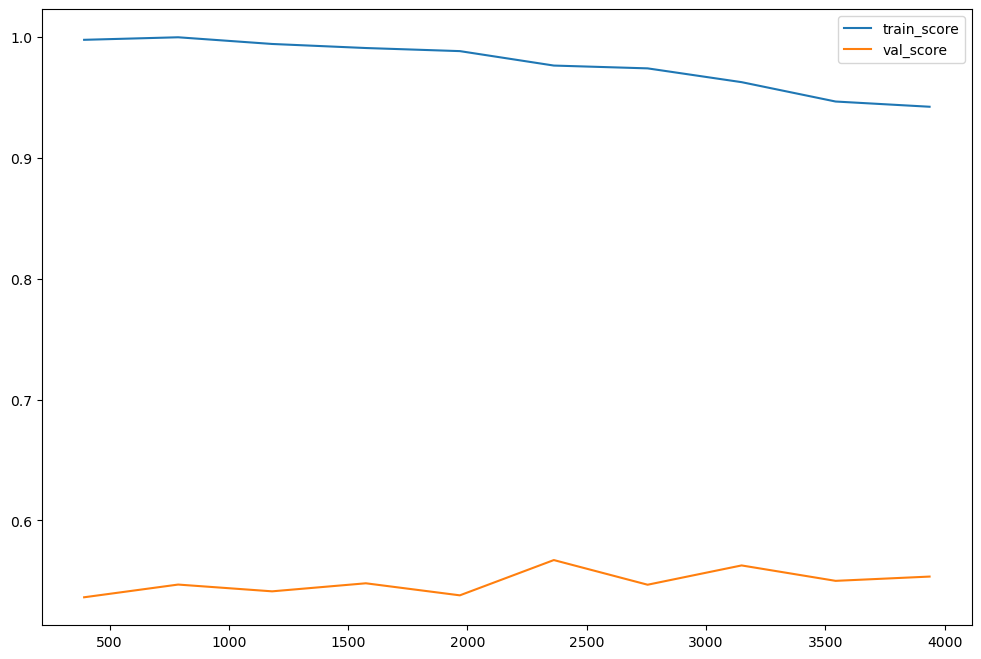

Dummy
precision----------------------------------------- 0.0
recal--------------------------------------------- 0.0
f1_score------------------------------------------ 0.0
class_report--------------------------------------               precision    recall  f1-score   support

           0       0.73      1.00      0.85       774
           1       0.00      0.00      0.00       281

    accuracy                           0.73      1055
   macro avg       0.37      0.50      0.42      1055
weighted avg       0.54      0.73      0.62      1055

confusion_matrix---------------------------------- [[774   0]
 [281   0]]
balance_accuracy---------------------------------- 0.5
roc_auc------------------------------------------- 0.5
pr_auc-------------------------------------------- 0.2663507109004739
brier--------------------------------------------- 0.195408375823935


/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resul

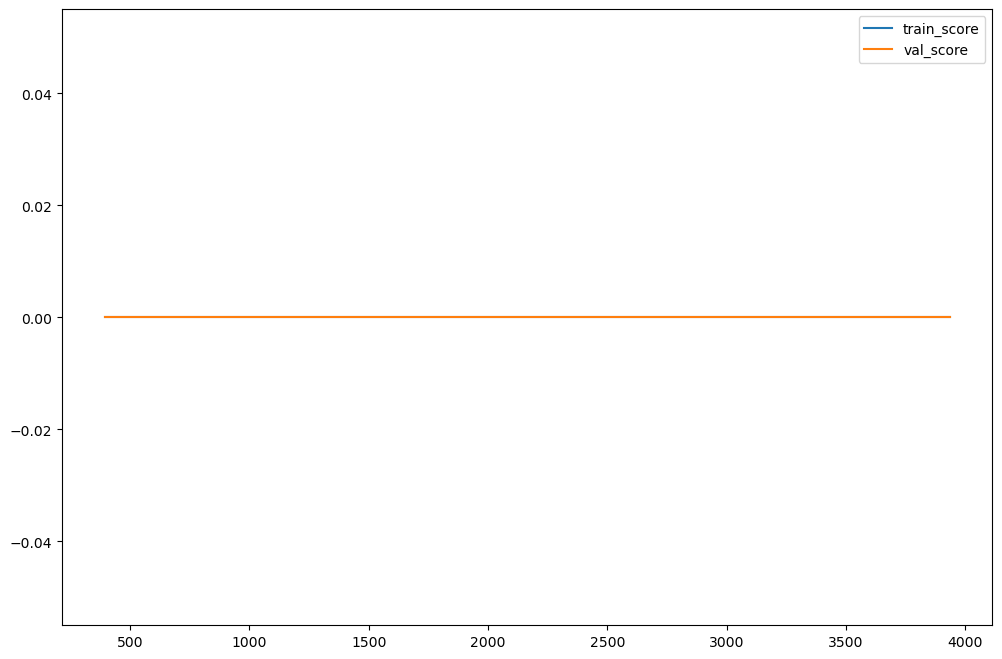

In [18]:
##============ baseline comparative =============
for name, model in dict_of_model.items():
    print(name)
    evaluation(model)


In [19]:
##================ Tableaux de comparaison de modèles ========

results = []

for name, model in dict_of_model.items():
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba),
        "PR-AUC": average_precision_score(y_val, y_proba)
    })

model_comparison = pd.DataFrame(results)

# Arrondir pour affichage
model_comparison_display = model_comparison.copy()
numeric_cols = model_comparison_display.select_dtypes(include="number").columns
model_comparison_display[numeric_cols] = model_comparison_display[numeric_cols].round(3)

model_comparison_display

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic,0.742,0.510,0.797,0.622,0.847,0.658
1,RandomForest,0.796,0.657,0.491,0.562,0.822,0.620
2,XGBoost,0.789,0.615,0.552,0.582,0.831,0.635
3,Dummy,0.734,0.000,0.000,0.000,0.500,0.266


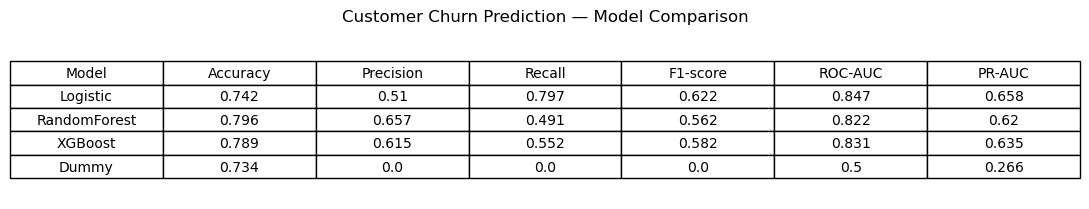

In [22]:

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.axis("off")

table = ax.table(
    cellText=model_comparison_display.values,
    colLabels=model_comparison_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Customer Churn Prediction — Model Comparison", pad=14)
plt.tight_layout()

plt.savefig(figures_dir /"model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Modèle à Optimiser:
On observe que le modèle régression linéaire offre les meilleurs performances globale notamment en terme de sensibilité (le score en d'environ 80%), ce qui est crucial dans un contexte de retention de clients. Les modèles les plus complexes comme le RandomForest ou encore le XGBoost n'apportent pas d'amélioration considérable illustrant propablement que la relation entre les variables et le churn relativement linéaire.
Donc je vais retenir ce modèle que je vais essayer d'améliorer.

## Optimisation du modèle avec RandomizedSearchCV puis GridSearchCV

In [11]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state= RANDOM_STATE)
param_grid={"model__C": [0.01, 0.1, 1, 10],
            "model__solver":["lbfgs", "liblinear"],
            "model__max_iter":[1000, 2000],
            "model__class_weight": ["balanced"]
           }

model = Pipeline(steps=[("preprocessor", preprocessor), 
                          ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                          random_state= RANDOM_STATE))
                          ])

In [12]:
grid = RandomizedSearchCV(model, param_grid, scoring= "f1",
                          cv=cv, random_state= RANDOM_STATE
                         )
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': ['balanced'], 'model__max_iter': [1000, 2000], 'model__solver': ['lbfgs', 'liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [17]:
##=================== enregistrement du meilleur modéle =========

from src.modeling import model_optimal, save_model

best_model, best_params, best_cv_score = model_optimal(
    preprocessor,
    X_train,
    y_train,
    random_state=RANDOM_STATE,
    scoring="f1"
)

save_model(best_model, project_root / "models" / "model_optimal.joblib")


In [14]:
##============== meilleures paramètres & meilleur score =========
best_model = grid.best_estimator_ 
print (grid.best_params_)
print(grid.best_score_)

{'model__solver': 'liblinear', 'model__max_iter': 1000, 'model__class_weight': 'balanced', 'model__C': 0.1}
0.6343194761990774


precision----------------------------------------- 0.4888
recall-------------------------------------------- 0.7786
f1_score------------------------------------------ 0.6006
balanced_accuracy--------------------------------- 0.7422
roc_auc------------------------------------------- 0.8217
pr_auc-------------------------------------------- 0.5771
brier--------------------------------------------- 0.1771

Classification report
              precision    recall  f1-score   support

           0       0.90      0.71      0.79       775
           1       0.49      0.78      0.60       280

    accuracy                           0.73      1055
   macro avg       0.69      0.74      0.70      1055
weighted avg       0.79      0.73      0.74      1055


Confusion matrix
[[547 228]
 [ 62 218]]


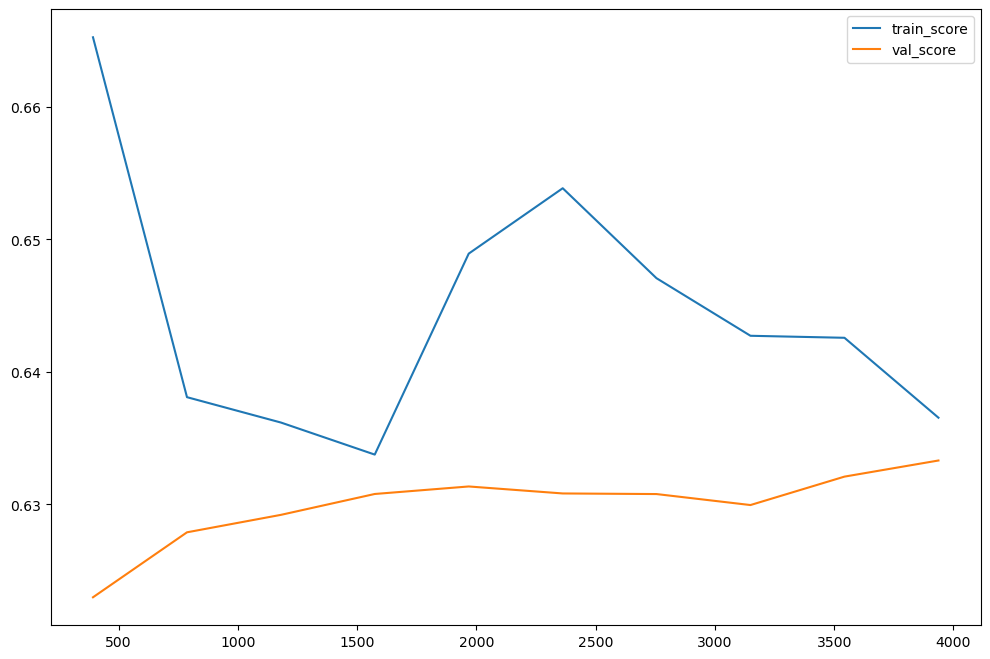

In [15]:
from src.evaluation import evaluation_model
from sklearn.model_selection import StratifiedKFold

evaluation_model(best_model, X_train, y_train, X_test, y_test, random_state=RANDOM_STATE)
    

## Optimisation du seuil

In [16]:
from sklearn.metrics import precision_recall_curve

y_proba = best_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

target_recall = 0.90

valid_idx = np.where(recall[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[-1]   # seuil le plus élevé respectant le recall cible
    best_threshold = thresholds[best_idx]
else:
    best_threshold = 0.5
best_threshold

0.3588357607971988

In [17]:
##========== top 1OO clients les plus risqués =======

top_clients = df.iloc[np.argsort(-y_proba)[:100]]
top_clients

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services,engagement_level
354,Female,1,No,No,21,No,No phone service,DSL,Yes,No,...,No,Month-to-month,Yes,Electronic check,41.90,840.10,Yes,intermediaires,2,faible
264,Female,0,Yes,No,45,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,One year,No,Mailed check,113.30,5032.25,No,fideles,8,moyen
589,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,Yes,...,Yes,Two year,No,Electronic check,90.40,6668.05,No,fideles,8,moyen
808,Male,0,Yes,No,40,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,101.30,4113.10,Yes,fideles,5,moyen
334,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,No,Mailed check,80.60,155.80,Yes,nouveaux,3,moyen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,Female,0,No,No,58,Yes,Yes,No,No internet service,No internet service,...,No internet service,Two year,No,Credit card (automatic),24.35,1423.85,No,fideles,2,moyen
864,Male,0,No,No,22,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),94.65,2104.55,Yes,intermediaires,4,moyen
252,Male,1,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,No,Electronic check,40.20,40.20,Yes,nouveaux,2,faible
389,Male,0,No,Yes,1,Yes,No,DSL,No,No,...,No,Month-to-month,No,Electronic check,44.00,44.00,No,nouveaux,1,faible


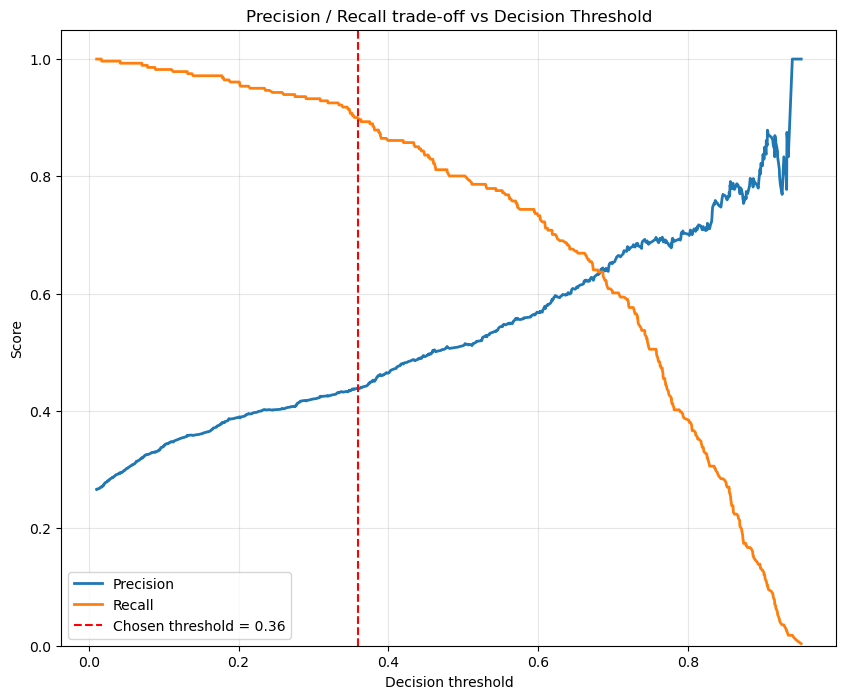

In [18]:
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 8))

plt.plot(thresholds, precision[:-1], label="Precision", linewidth=2)
plt.plot(thresholds, recall[:-1], label="Recall", linewidth=2)

plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Chosen threshold = {best_threshold:.2f}")

plt.title("Precision / Recall trade-off vs Decision Threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.savefig(figures_dir / "precision_recall_vs_threshold.png", bbox_inches="tight")
plt.show()

In [19]:

##========= modéle final =============

def model_final(model, X, threshold):
    y_proba = model.predict_proba(X)[:,1]
    return (y_proba > threshold).astype(int)
    

In [20]:
y_pred = model_final(grid.best_estimator_, X_val, best_threshold)

precision_score(y_val, y_pred)
recall_score(y_val, y_pred)
f1_score(y_val, y_pred)

0.5887850467289719

In [21]:
f1_score(y_val, y_pred)

0.5887850467289719

In [22]:
recall_score(y_val, y_pred)

0.896797153024911

## Caractéristiques les plus importantes pour notre modèle

In [24]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    grid.best_estimator_,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X_val.columns
).sort_values(ascending=False)

importance

tenure              0.021422
tenure_group        0.007583
InternetService     0.005687
OnlineSecurity      0.005498
TechSupport         0.004171
num_services        0.002085
engagement_level    0.001896
SeniorCitizen       0.001706
OnlineBackup        0.000379
Partner             0.000190
gender              0.000000
DeviceProtection   -0.000190
Contract           -0.001137
PaymentMethod      -0.001327
StreamingTV        -0.001517
PhoneService       -0.002464
MultipleLines      -0.003033
MonthlyCharges     -0.003412
PaperlessBilling   -0.004929
TotalCharges       -0.005308
StreamingMovies    -0.006066
Dependents         -0.006825
Length: 22, dtype: float64

## Courbe de Calibration

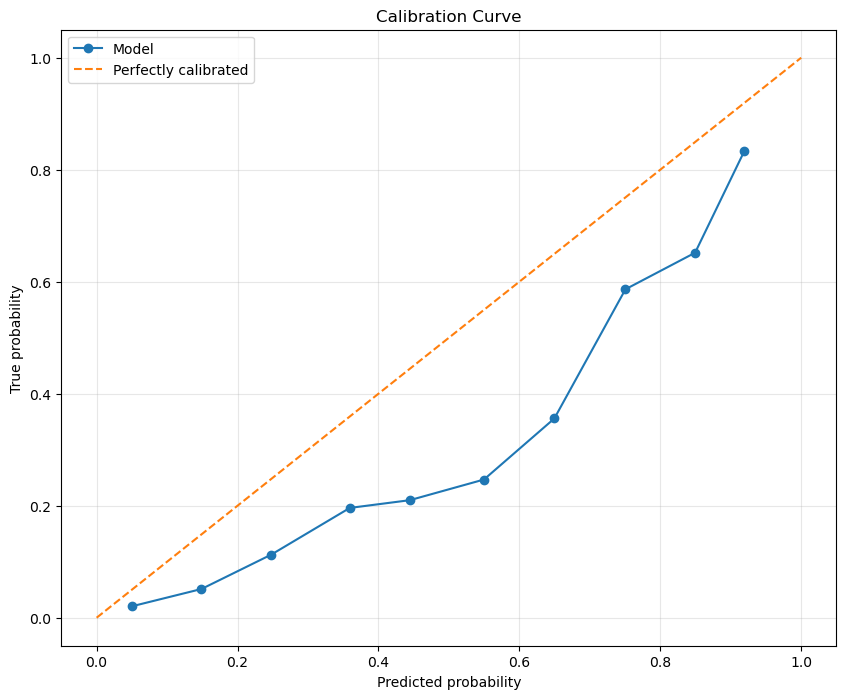

In [25]:
from sklearn.calibration import calibration_curve

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

y_proba = best_model.predict_proba(X_val)[:,1]

prob_true, prob_pred = calibration_curve(y_val, y_proba, n_bins=10)

plt.figure(figsize=(10,8))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1],[0,1], linestyle='--', label="Perfectly calibrated")

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(figures_dir / "calibration_curve.png", bbox_inches="tight")
plt.show()

## Interprétation globale:

- **Validation des résultats du modèle**:
   - `recall_score`≈ 0.90 sur l'ensemble de validation, autrement dit qu'il identie correctement environ 90% des clients
      susceptibles de resilier
   - `precision_score`≈ 0.60
   - `f1_score`≈ 0.60, traduit un compris équilibré entre precision et recall
- **Interprétation**:
  - bon équilibre globale
  - recall solide
  - modèle utilisable metier

---

- **Choix du modèle**: j'ai retenu le modèle de régression logistique, grâce à ses performances globales,
  notamment sa capacité à identifier efficacement les clients susceptibles de churn, tout en gardant un bon équilibre entre
  la precision et la sensibilité.
  
- **Seuil de decision**: plus tôt que d'utiliser le seuil de $0.5$ par défaut, j'ai essayé de trouver un bon seuil (≈ 0.36),      basé sur l'analyse du compromis precision/recall. Cela permet de mieux contrôler les Faux négatifs, c'est qui est cruciale 
   dans un contexte de prediction de churn.
   A noter qu'un seuil plus faible permet mieux la détection des clients à fort risque de churn.

- **Cible métier**: en tenant en compte nos différents résultats, je peux dire que ce modèles peux bien être utiliser pour       classer les clients selon leurs probabilités de churn, et surtout prioriser les actions de rétention sur les clients à haut    risques.

---

- **Courbe de calibration**: elle montre que les probabilités qui sont prédites par le modèle sont globalement sous estimés.     en effet pour une probabilité prédite par le modèle donnée, la probabilité réelle observée est souvent plus faible que celle   attendue dans un modèle parfaitement calibré.
  on peut l'observer sur la ligne diagonale.

  Autrement dit que le modèle à tendance à être trop confiant dans ses prédictions (ie une probabilité de 0.8, signifie pas      systématiquement 80% de churn réel.

  Cette observation permet de comprendre qu'une **probabilité n'est pas une certitude** et que la calibration permet d'évaluer   la **fiabilité des scores prédits**. Cependant le modèle reste toujours exploitable pour le classement des clients à risque.

---

- **Variables importantes**: elle permet d'identifier les principaux leviers d'actions pour réduire le churn, en particulier     en ciblant les clients récents et ceux qui sont souscrits à moins d'offres de services.

En résumé on peut dire que le modèle retenu est le modèle de régression logistique, avec un seuil de décision bien ajusté avec des métriques qui reflètent bien la réalité metier du problème.